In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.utils.data as Data
import matplotlib.pyplot as plt
import time
import math
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
torch.manual_seed(42)
np.random.seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"当前运行设备: {device}")

当前运行设备: cuda


In [2]:
data_path = 'traffic-flow/traffic.npz'
try:
    raw_data = np.load(data_path)['data']
    print(f"数据加载成功，形状: {raw_data.shape}")
except FileNotFoundError:
    print("未找到 PEMS04.npz，正在生成随机模拟数据用于演示...")
    raw_data = np.random.randn(16992, 307, 3)

数据加载成功，形状: (17856, 170, 3)


In [3]:
node_data = raw_data[:, 0, :] 

# 标准化
scaler = StandardScaler()
scaled_data = scaler.fit_transform(node_data)

# 构建数据集
def create_dataset(dataset, look_back=12):
    dataX, dataY = [], []
    for i in range(len(dataset) - look_back):
        dataX.append(dataset[i:(i + look_back), :])
        dataY.append(dataset[i + look_back, 0]) # 仅预测流量
    return np.array(dataX), np.array(dataY)

SEQ_LEN = 12 
X, y = create_dataset(scaled_data, SEQ_LEN)

# 划分训练集/测试集 (80/20)
train_size = int(len(X) * 0.8)
train_X = torch.from_numpy(X[:train_size]).type(torch.FloatTensor)
train_Y = torch.from_numpy(y[:train_size]).type(torch.FloatTensor)
test_X = torch.from_numpy(X[train_size:]).type(torch.FloatTensor)
test_Y = torch.from_numpy(y[train_size:]).type(torch.FloatTensor)

# DataLoader
train_loader = Data.DataLoader(
    dataset=Data.TensorDataset(train_X, train_Y), 
    batch_size=64, 
    shuffle=True
)

In [4]:
class ManualRNN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(ManualRNN, self).__init__()
        self.hidden_dim = hidden_dim
        
        # --- 手动定义权重参数 ---
        # input (x) -> hidden (h)
        self.W_ih = nn.Parameter(torch.Tensor(hidden_dim, input_dim))
        # hidden (h_prev) -> hidden (h_next)
        self.W_hh = nn.Parameter(torch.Tensor(hidden_dim, hidden_dim))
        # 偏置
        self.b_ih = nn.Parameter(torch.Tensor(hidden_dim))
        self.b_hh = nn.Parameter(torch.Tensor(hidden_dim))
        
        # 输出层
        self.fc = nn.Linear(hidden_dim, output_dim)
        
        # 初始化权重 (非常关键)
        self.init_weights()

    def init_weights(self):
        stdv = 1.0 / math.sqrt(self.hidden_dim)
        for weight in self.parameters():
            weight.data.uniform_(-stdv, stdv)

    def forward(self, x):
        """
        x shape: (batch_size, seq_len, input_dim)
        """
        batch_size, seq_len, _ = x.size()
        
        # 初始化 h0
        h_t = torch.zeros(batch_size, self.hidden_dim).to(x.device)
        
        # --- 手动循环时间步 ---
        for t in range(seq_len):
            x_t = x[:, t, :]
            # 核心公式: h_t = tanh( linear(x) + linear(h_prev) )
            linear_x = torch.matmul(x_t, self.W_ih.t()) + self.b_ih
            linear_h = torch.matmul(h_t, self.W_hh.t()) + self.b_hh
            h_t = torch.tanh(linear_x + linear_h)
            
        return self.fc(h_t)
    
def calculate_metrics(y_true, y_pred):
    # 1. RMSE
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    
    # 2. MAE
    mae = mean_absolute_error(y_true, y_pred)
    
    # 3. MAPE
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    
    return mae, rmse, mape


def train_manual_model(model, train_loader, test_x, test_y, scaler, epochs=20):
    model.to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    
    # 记录字典 (Train 和 Test 分开)
    history = {
        'train_loss': [], 'test_loss': [],
        'train_mae': [], 'test_mae': [],
        'train_rmse': [], 'test_rmse': [],
        'train_mape': [], 'test_mape': [],
        'time': []
    }
    
    print(f"开始训练 (对比 Train/Test 指标)...")
    
    for epoch in range(epochs):
        epoch_start = time.time()
        
        # --- 1. 训练阶段 ---  
        model.train()
        train_loss_accum = 0
        
        # 为了计算训练集的真实指标，我们需要收集这一轮所有的预测值和真实值
        train_preds = []
        train_trues = []
        
        for b_x, b_y in train_loader:
            b_x, b_y = b_x.to(device), b_y.to(device)
            
            optimizer.zero_grad()
            output = model(b_x)
            loss = criterion(output.squeeze(), b_y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            
            train_loss_accum += loss.item()
            
            # 收集训练数据用于计算指标
            train_preds.append(output.squeeze().detach().cpu().numpy())
            train_trues.append(b_y.detach().cpu().numpy())
        
        avg_train_loss = train_loss_accum / len(train_loader)
        epoch_end = time.time()
        epoch_time = epoch_end - epoch_start
        
        # 拼接所有 batch
        train_preds = np.concatenate(train_preds)
        train_trues = np.concatenate(train_trues)
        
        # 反标准化
        d_p = np.zeros((len(train_preds), 3)); d_p[:, 0] = train_preds
        inv_train_preds = scaler.inverse_transform(d_p)[:, 0]
        
        d_t = np.zeros((len(train_trues), 3)); d_t[:, 0] = train_trues
        inv_train_trues = scaler.inverse_transform(d_t)[:, 0]
        
        # 计算训练集的 MAE, RMSE, MAPE
        train_mae, train_rmse, train_mape = calculate_metrics(inv_train_trues, inv_train_preds)
        
        # --- 2. 计算测试集指标 (Test Metrics) ---
        model.eval()
        with torch.no_grad():
            test_in = test_x.to(device)
            test_out = model(test_in)
            test_loss = criterion(test_out.squeeze(), test_y.to(device)).item()
            
            test_out = test_out.cpu().numpy()
            
            # 反标准化
            d_p = np.zeros((len(test_out), 3)); d_p[:, 0] = test_out.flatten()
            inv_test_preds = scaler.inverse_transform(d_p)[:, 0]
            
            d_t = np.zeros((len(test_y), 3)); d_t[:, 0] = test_y.numpy().flatten()
            inv_test_trues = scaler.inverse_transform(d_t)[:, 0]
            
            # 计算测试集的 MAE, RMSE, MAPE
            test_mae, test_rmse, test_mape = calculate_metrics(inv_test_trues, inv_test_preds)

        # --- 3. 记录所有历史 ---
        history['train_loss'].append(avg_train_loss)
        history['test_loss'].append(test_loss)
        history['train_mae'].append(train_mae)
        history['test_mae'].append(test_mae)
        history['train_rmse'].append(train_rmse)
        history['test_rmse'].append(test_rmse)
        history['train_mape'].append(train_mape)
        history['test_mape'].append(test_mape)
        history['time'].append(epoch_time)
        
        if (epoch+1) % 5 == 0:
            print(f"Epoch {epoch+1} | T_Loss: {avg_train_loss:.4f} V_Loss: {test_loss:.4f} | "
                  f"T_MAE: {train_mae:.4f} V_MAE: {test_mae:.4f} | "
                  f"T_RMSE: {train_rmse:.4f} V_RMSE: {test_rmse:.4f} | "
                  f"T_MAPE: {train_mape:.4f} V_MAPE: {test_mape:.4f}")

    return history


In [5]:
INPUT_DIM = 3
HIDDEN_DIM = 64
OUTPUT_DIM = 1
epochs = 20

model = ManualRNN(INPUT_DIM, HIDDEN_DIM, OUTPUT_DIM)

# 运行训练 (传入 test_X, test_Y 和 scaler 以便内部计算指标)
history = train_manual_model(
    model, train_loader, test_X, test_Y, scaler, epochs=epochs
)

开始训练 (对比 Train/Test 指标)...
Epoch 5 | T_Loss: 0.0339 V_Loss: 0.0402 | T_MAE: 19.9032 V_MAE: 21.7247 | T_RMSE: 26.9137 V_RMSE: 29.2737 | T_MAPE: 7.4819 V_MAPE: 8.3830
Epoch 10 | T_Loss: 0.0337 V_Loss: 0.0403 | T_MAE: 19.8433 V_MAE: 21.5757 | T_RMSE: 26.8121 V_RMSE: 29.3067 | T_MAPE: 7.5149 V_MAPE: 7.7086
Epoch 15 | T_Loss: 0.0331 V_Loss: 0.0416 | T_MAE: 19.5359 V_MAE: 21.9676 | T_RMSE: 26.4819 V_RMSE: 29.7577 | T_MAPE: 7.3665 V_MAPE: 7.9005
Epoch 20 | T_Loss: 0.0331 V_Loss: 0.0387 | T_MAE: 19.6934 V_MAE: 21.2689 | T_RMSE: 26.5950 V_RMSE: 28.7235 | T_MAPE: 7.4226 V_MAPE: 7.9101


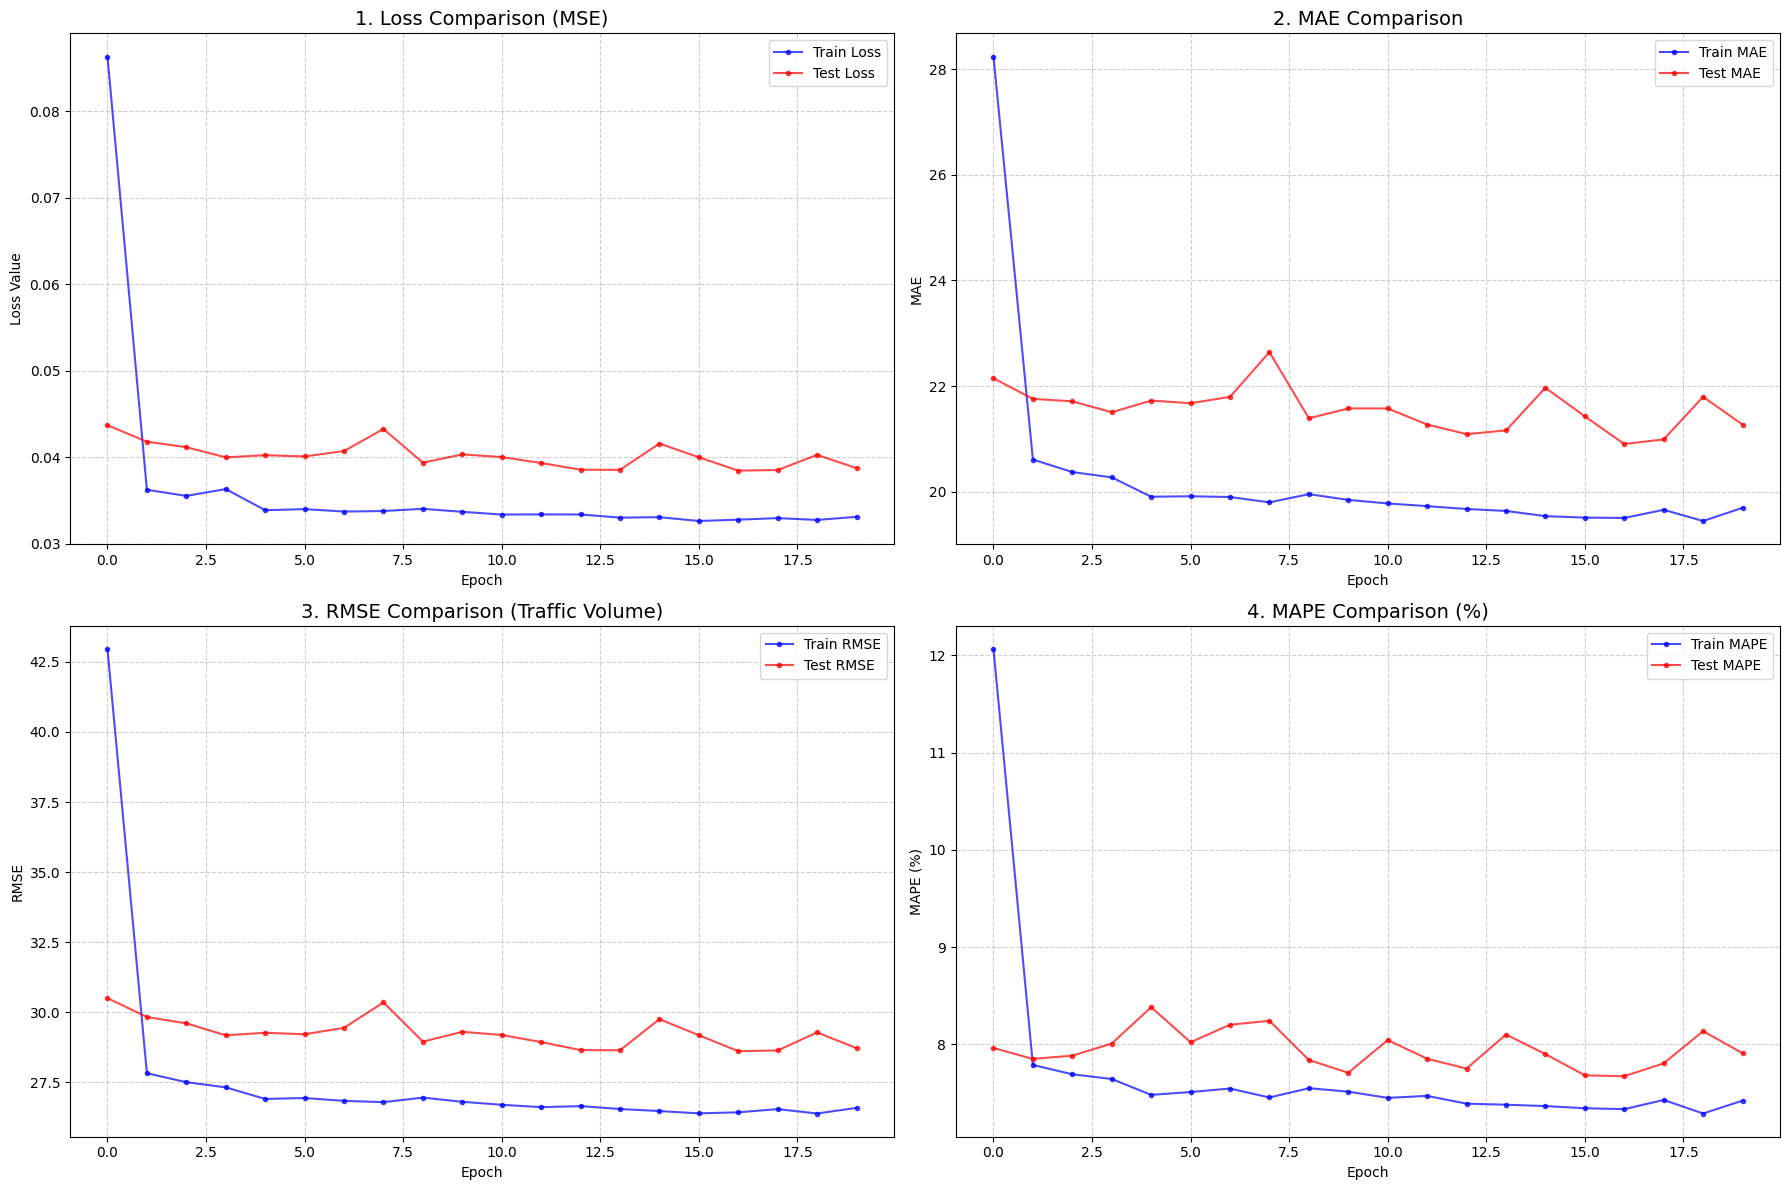

In [7]:
plt.figure(figsize=(18, 12))

# --- 子图 1: Loss 对比 ---
plt.subplot(2, 2, 1)
plt.plot(history['train_loss'], label='Train Loss', marker='.', color='blue', alpha=0.7)
plt.plot(history['test_loss'], label='Test Loss', marker='.', color='red', alpha=0.7)
plt.title("1. Loss Comparison (MSE)", fontsize=14)
plt.xlabel("Epoch")
plt.ylabel("Loss Value")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# --- 子图 2: MAE 对比 ---
plt.subplot(2, 2, 2)
plt.plot(history['train_mae'], label='Train MAE', marker='.', color='blue', alpha=0.7)
plt.plot(history['test_mae'], label='Test MAE', marker='.', color='red', alpha=0.7)
plt.title("2. MAE Comparison", fontsize=14)
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# --- 子图 3: RMSE 对比 ---
plt.subplot(2, 2, 3)
plt.plot(history['train_rmse'], label='Train RMSE', marker='.', color='blue', alpha=0.7)
plt.plot(history['test_rmse'], label='Test RMSE', marker='.', color='red', alpha=0.7)
plt.title("3. RMSE Comparison (Traffic Volume)", fontsize=14)
plt.xlabel("Epoch")
plt.ylabel("RMSE")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# --- 子图 4: MAPE 对比 ---
plt.subplot(2, 2, 4)
plt.plot(history['train_mape'], label='Train MAPE', marker='.', color='blue', alpha=0.7)
plt.plot(history['test_mape'], label='Test MAPE', marker='.', color='red', alpha=0.7)
plt.title("4. MAPE Comparison (%)", fontsize=14)
plt.xlabel("Epoch")
plt.ylabel("MAPE (%)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


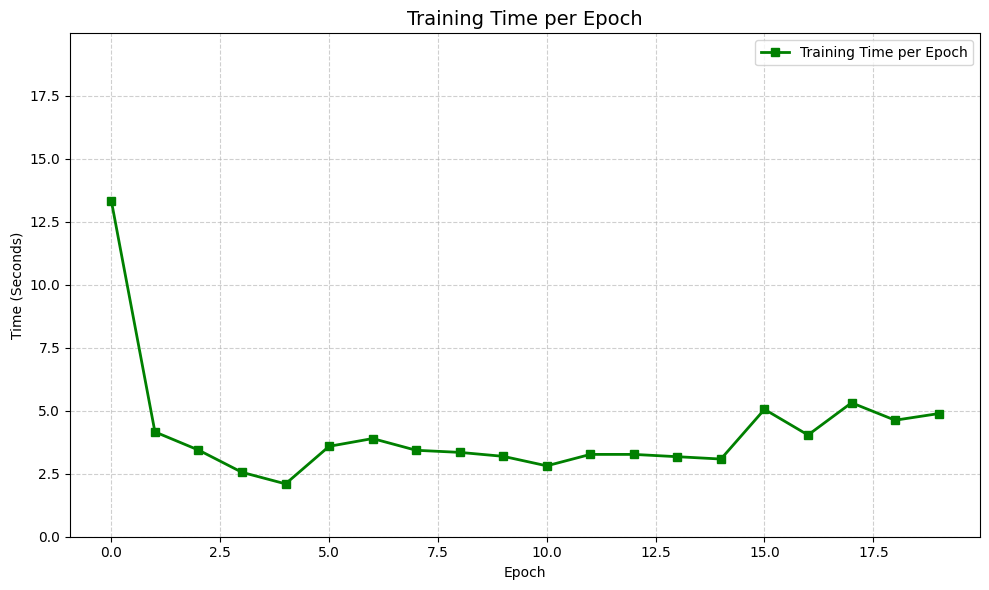

In [8]:
# 绘制训练时间折线图
plt.figure(figsize=(10, 6))
# 训练时间对比
plt.plot(history['time'], marker='s', color='green', linewidth=2, label='Training Time per Epoch')
plt.title("Training Time per Epoch", fontsize=14)
plt.xlabel("Epoch")
plt.ylabel("Time (Seconds)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.ylim(0, max(history['time']) * 1.5)  # 留出顶部空间

plt.tight_layout()
plt.show()


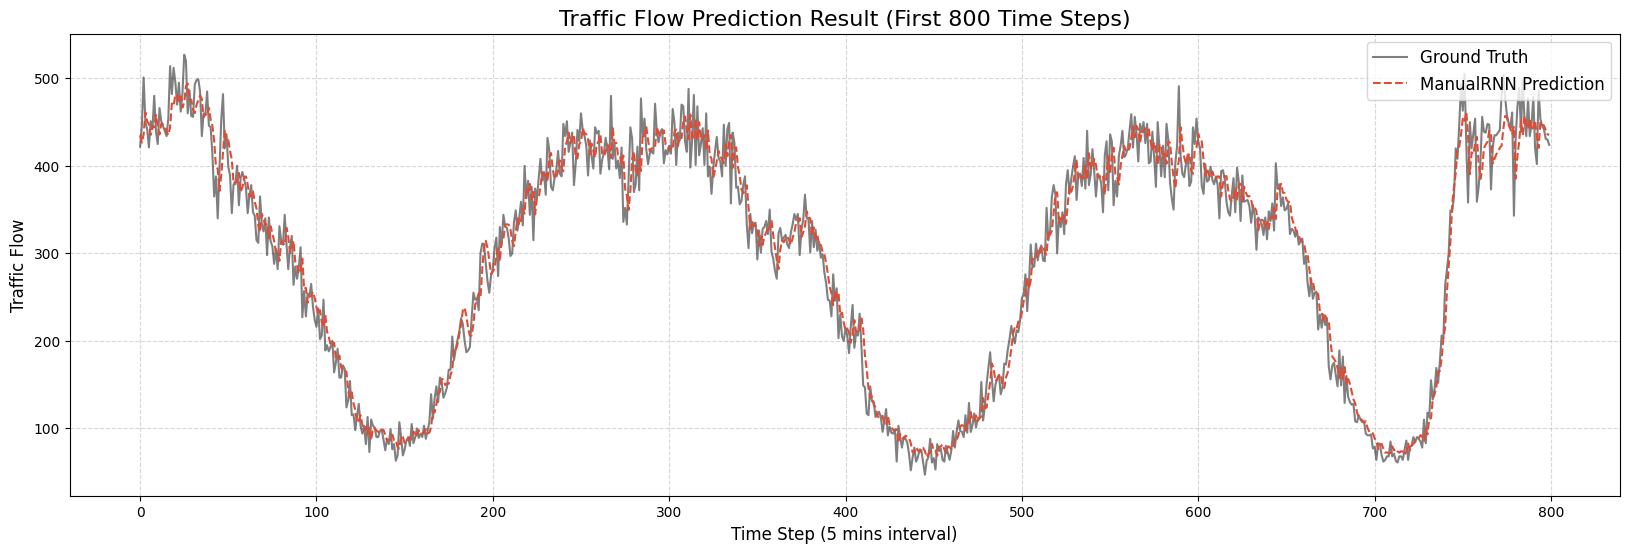

In [9]:
model.eval()
with torch.no_grad():
    preds = model(test_X.to(device)).cpu().numpy()

# 反标准化
dummy_p = np.zeros((len(preds), 3)); dummy_p[:, 0] = preds.flatten()
final_preds = scaler.inverse_transform(dummy_p)[:, 0]

dummy_t = np.zeros((len(test_Y), 3)); dummy_t[:, 0] = test_Y.numpy().flatten()
final_true = scaler.inverse_transform(dummy_t)[:, 0]

# 绘制
display_len = 800 # 显示约 2-3 天的数据
plt.figure(figsize=(20, 6))
 # 示意图标记，实际代码在下方
plt.plot(final_true[:display_len], label='Ground Truth', color='black', alpha=0.5)
plt.plot(final_preds[:display_len], label='ManualRNN Prediction', color='#E24A33', linewidth=1.5, linestyle='--')
plt.title(f"Traffic Flow Prediction Result (First {display_len} Time Steps)", fontsize=16)
plt.xlabel("Time Step (5 mins interval)", fontsize=12)
plt.ylabel("Traffic Flow", fontsize=12)
plt.legend(fontsize=12, loc='upper right')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.show()